In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\Ameet Computer\OneDrive\Pictures\Saved Pictures\Time series forecasting\TimeSeries_TotalSolarGen_and_Load_IT_2016.csv")
df.head(6)

,utc_timestamp,IT_load_new,IT_solar_generation
0,2016-01-01T00:00:00Z,21665.0,1
1,2016-01-01T01:00:00Z,20260.0,0
2,2016-01-01T02:00:00Z,19056.0,0
3,2016-01-01T03:00:00Z,18407.0,0
4,2016-01-01T04:00:00Z,18425.0,0
5,2016-01-01T05:00:00Z,19261.0,0


In [3]:
####change timestamp to date

df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])

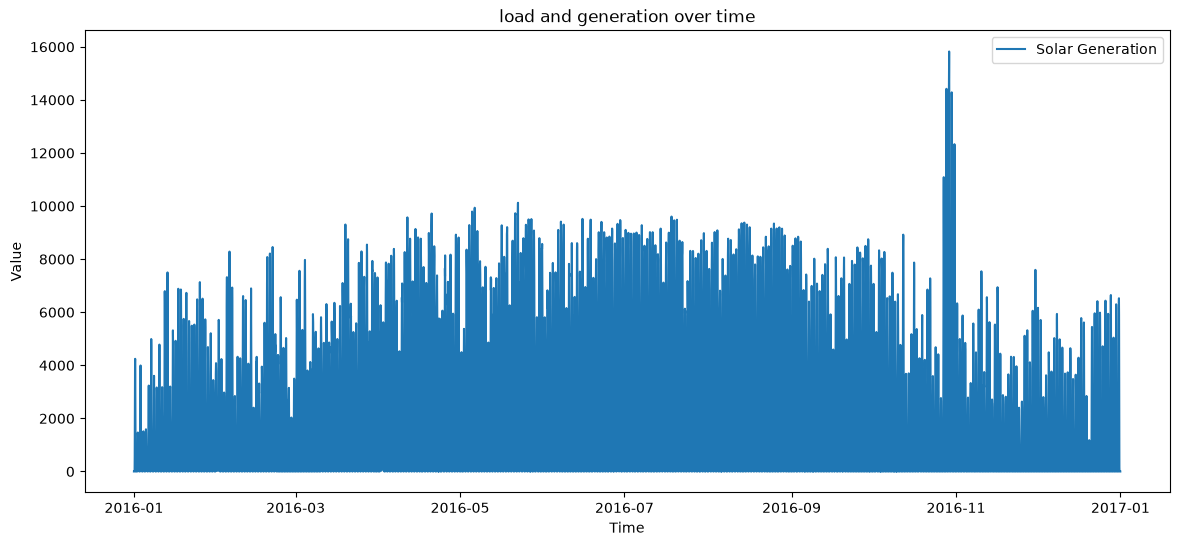

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df["utc_timestamp"], df["IT_solar_generation"], label="Solar Generation")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.title("load and generation over time")
plt.show()


The graph shows solar energy generation over time. I can see that solar generation changes significantly throughout the year. The generation appears to be higher during the middle months of the year and lower toward the beginning and end of the year. There are also some sudden increases and decreases in generation. This suggests that solar energy generation may have a seasonal pattern and is influenced by factors that change over time.

In [7]:
print(df.index)
print(df.index.dtype)

RangeIndex(start=0, stop=8784, step=1)
int64


In [8]:
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])

In [10]:
df = df.sort_values("utc_timestamp")
df = df.set_index("utc_timestamp")

In [11]:
df.index.to_series().diff().value_counts().head()

utc_timestamp
0 days 01:00:00    8783
Name: count, dtype: int64

Our solar energy data is recorded every 1 hour. 

So we have hourly time-series data.

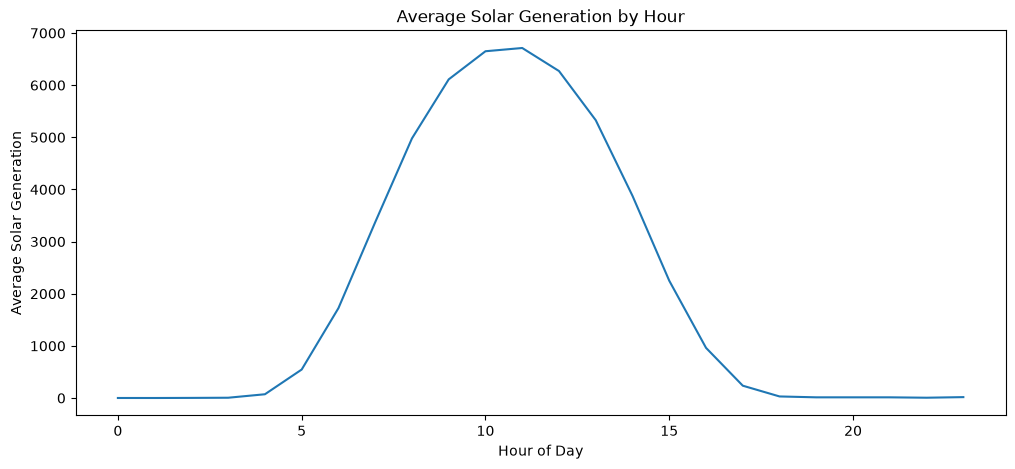

In [15]:
df["hour"] = df.index.hour

hourly_pattern = df.groupby("hour")["IT_solar_generation"].mean()

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_pattern.index,
    hourly_pattern.values
)

plt.title("Average Solar Generation by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Solar Generation")

plt.show()

The graph shows a clear daily seasonal pattern in solar generation. Solar generation is almost zero during nighttime hours, begins increasing in the morning, reaches its peak around 11:00 AM, and gradually decreases during the afternoon before becoming nearly zero again in the evening. This repeating pattern indicates strong daily seasonality in the solar generation data.

In [16]:
#######Check Stationarity using the ADF test
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["IT_solar_generation"].dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.741334582271169
p-value: 6.265438259037399e-07


PAST DATA                         FUTURE DATA
TRAINING DATA                    TESTING DATA

██████████████████████████████   ██████████

In [17]:
train = df["IT_solar_generation"].iloc[:-168]
test = df["IT_solar_generation"].iloc[-168:]

print("Training data:", len(train))
print("Testing data:", len(test))

Training data: 8616
Testing data: 168


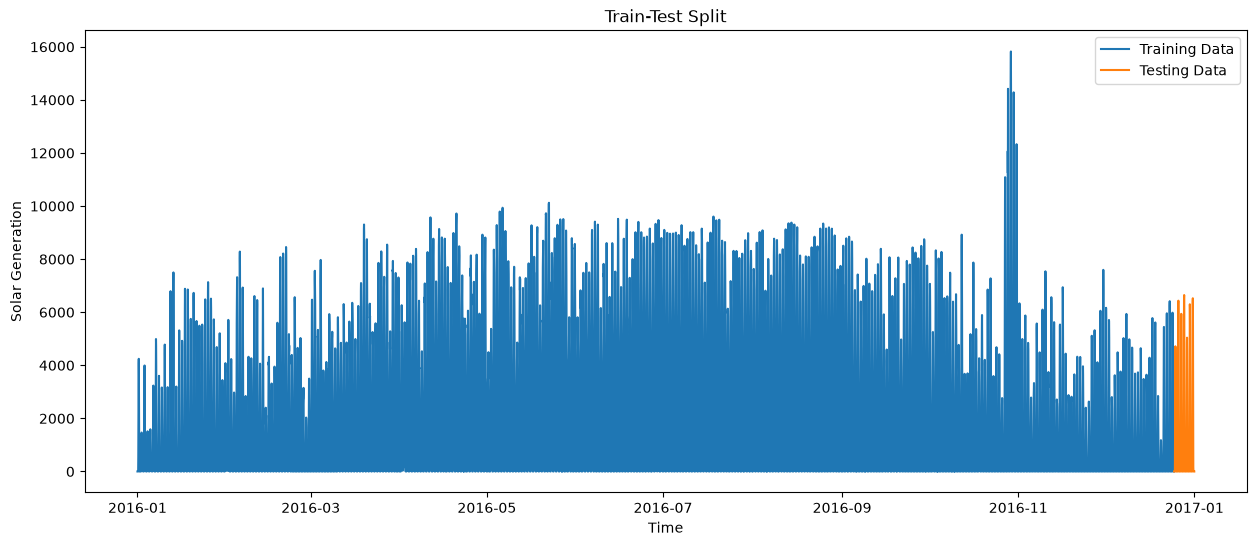

In [18]:
plt.figure(figsize=(15, 6))

plt.plot(train, label="Training Data")
plt.plot(test, label="Testing Data")

plt.title("Train-Test Split")
plt.xlabel("Time")
plt.ylabel("Solar Generation")

plt.legend()
plt.show()

Because our data has a 24-hour seasonal pattern, I recommend a Seasonal Naive Forecast.

In [19]:
import numpy as np

# Seasonal Naive Forecast
seasonal_naive_forecast = train.iloc[-24:].values

# Repeat the last 24 hours for the 7-day test period
predictions = np.tile(
    seasonal_naive_forecast,
    7
)

# Make sure prediction length matches test length
predictions = predictions[:len(test)]

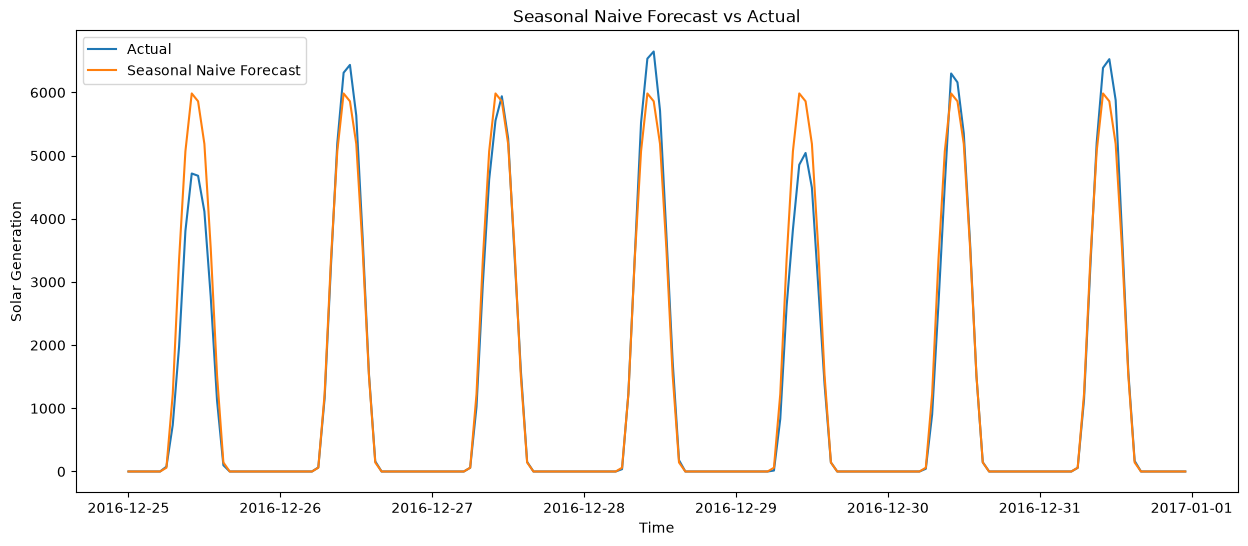

In [20]:
plt.figure(figsize=(15, 6))

plt.plot(test.index, test.values, label="Actual")
plt.plot(test.index, predictions, label="Seasonal Naive Forecast")

plt.title("Seasonal Naive Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Solar Generation")

plt.legend()
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test, predictions)

rmse = np.sqrt(
    mean_squared_error(test, predictions)
)

print("Seasonal Naive MAE:", mae)
print("Seasonal Naive RMSE:", rmse)

Seasonal Naive MAE: 149.0952380952381
Seasonal Naive RMSE: 333.9543738439786


ARIMA BUILDING

In [22]:
##ARIMA(1, 0, 1)
from statsmodels.tsa.arima.model import ARIMA

# Create ARIMA model
model = ARIMA(
    train,
    order=(1, 0, 1)
)

# Fit the model
arima_fit = model.fit()

# Forecast the test period
arima_forecast = arima_fit.forecast(
    steps=len(test)
)

print(arima_forecast.head())

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


2016-12-25 00:00:00+00:00     54.586055
2016-12-25 01:00:00+00:00    200.673947
2016-12-25 02:00:00+00:00    336.145875
2016-12-25 03:00:00+00:00    461.773283
2016-12-25 04:00:00+00:00    578.271555
Freq: h, Name: predicted_mean, dtype: float64


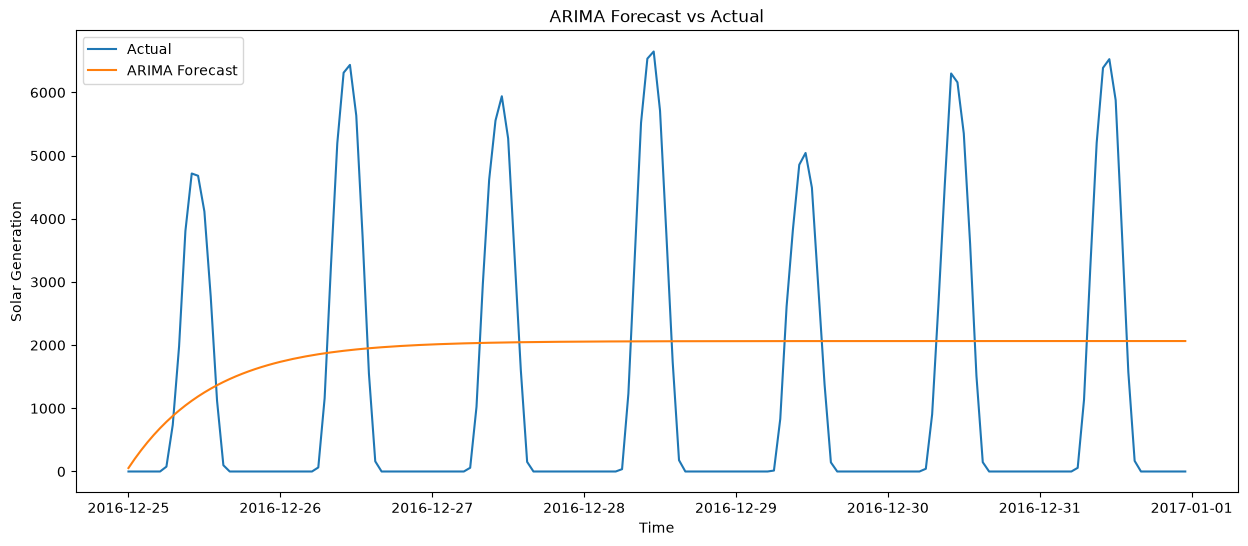

In [23]:
plt.figure(figsize=(15, 6))

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    test.index,
    arima_forecast.values,
    label="ARIMA Forecast"
)

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Solar Generation")

plt.legend()

plt.show()

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

arima_mae = mean_absolute_error(
    test,
    arima_forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_forecast
    )
)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 1996.5045288747074
ARIMA RMSE: 2187.624957368328


SARIMA MODEL BUILDING

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Build SARIMA model
sarima_model = SARIMAX(
    train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Fit model
sarima_fit = sarima_model.fit()

# Forecast
sarima_forecast = sarima_fit.forecast(
    steps=len(test)
)

print(sarima_forecast.head())

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2016-12-25 00:00:00+00:00   -0.082555
2016-12-25 01:00:00+00:00   -0.026136
2016-12-25 02:00:00+00:00    0.038938
2016-12-25 03:00:00+00:00   -0.093815
2016-12-25 04:00:00+00:00   -0.082981
Freq: h, Name: predicted_mean, dtype: float64


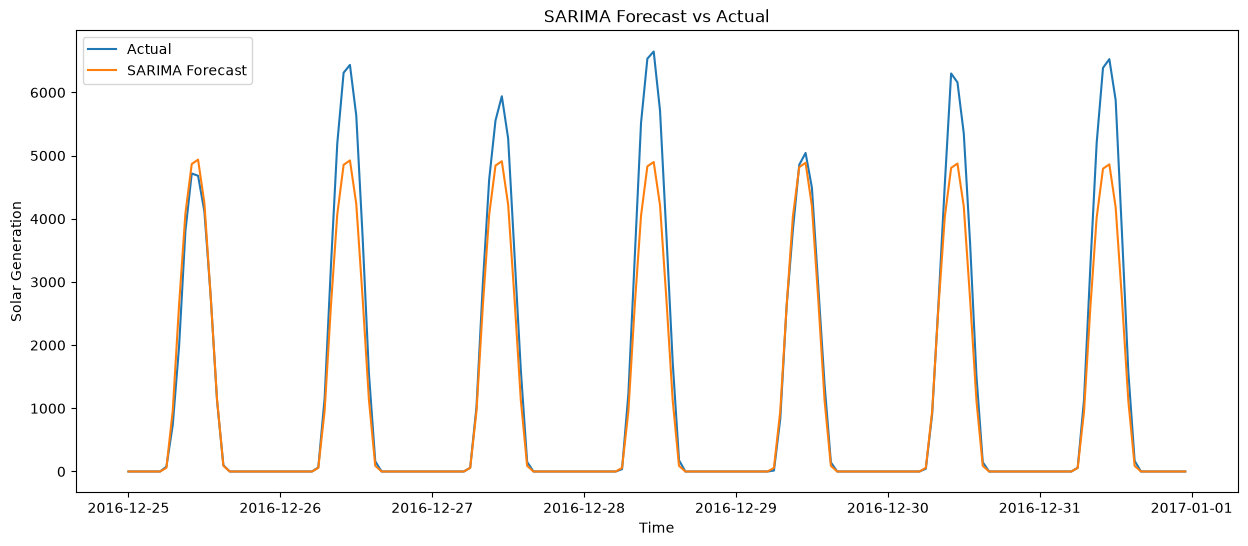

In [26]:
plt.figure(figsize=(15, 6))

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    test.index,
    sarima_forecast.values,
    label="SARIMA Forecast"
)

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel("Solar Generation")

plt.legend()

plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarima_mae = mean_absolute_error(
    test,
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_forecast
    )
)

print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)

SARIMA MAE: 235.4877358976604
SARIMA RMSE: 512.7889488854863


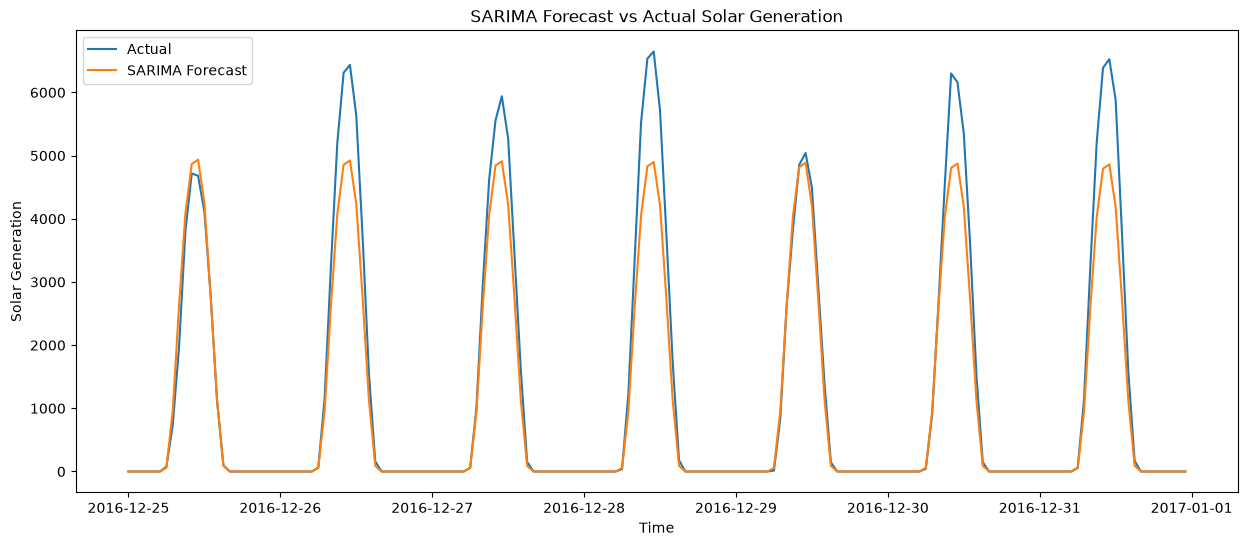

In [28]:
plt.figure(figsize=(15, 6))

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    test.index,
    sarima_forecast.values,
    label="SARIMA Forecast"
)

plt.title("SARIMA Forecast vs Actual Solar Generation")
plt.xlabel("Time")
plt.ylabel("Solar Generation")

plt.legend()
plt.show()

In [29]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "MAE": [arima_mae, sarima_mae],
    "RMSE": [arima_rmse, sarima_rmse]
})

print(comparison)

    Model          MAE         RMSE
0   ARIMA  1996.504529  2187.624957
1  SARIMA   235.487736   512.788949


Train SARIMA on ALL your historical data

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_model = SARIMAX(
    df["IT_solar_generation"],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fit = final_model.fit()

print(final_fit.summary())

c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                IT_solar_generation   No. Observations:                 8784
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -61840.665
Date:                            Wed, 22 Jul 2026   AIC                         123691.330
Time:                                    06:42:14   BIC                         123726.719
Sample:                                01-01-2016   HQIC                        123703.389
                                     - 12-31-2016                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8851      0.002    456.807      0.000       0.881       0.889
ma.L1          2.8357      0.020   

In [31]:
future_forecast = final_fit.forecast(steps=168)

print(future_forecast)

2017-01-01 00:00:00+00:00    0.075316
2017-01-01 01:00:00+00:00    0.138872
2017-01-01 02:00:00+00:00    0.078062
2017-01-01 03:00:00+00:00    0.045592
2017-01-01 04:00:00+00:00    0.040355
                               ...   
2017-01-07 19:00:00+00:00    0.007215
2017-01-07 20:00:00+00:00    0.223549
2017-01-07 21:00:00+00:00    0.171219
2017-01-07 22:00:00+00:00    0.190297
2017-01-07 23:00:00+00:00    0.016337
Freq: h, Name: predicted_mean, Length: 168, dtype: float64


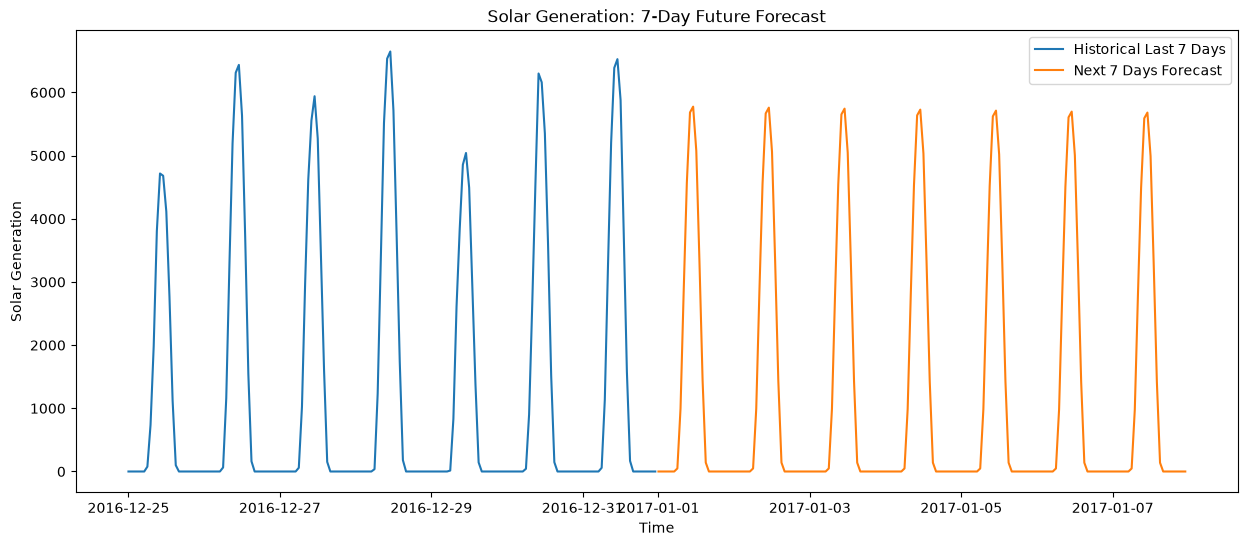

In [32]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["IT_solar_generation"].iloc[-168:],
    label="Historical Last 7 Days"
)

plt.plot(
    future_forecast.index,
    future_forecast.values,
    label="Next 7 Days Forecast"
)

plt.title("Solar Generation: 7-Day Future Forecast")
plt.xlabel("Time")
plt.ylabel("Solar Generation")

plt.legend()

plt.show()

In [33]:
forecast_df = pd.DataFrame({
    "Forecasted_Solar_Generation": future_forecast
})

print(forecast_df.head(24))

                           Forecasted_Solar_Generation
2017-01-01 00:00:00+00:00                     0.075316
2017-01-01 01:00:00+00:00                     0.138872
2017-01-01 02:00:00+00:00                     0.078062
2017-01-01 03:00:00+00:00                     0.045592
2017-01-01 04:00:00+00:00                     0.040355
2017-01-01 05:00:00+00:00                     0.035848
2017-01-01 06:00:00+00:00                    48.599323
2017-01-01 07:00:00+00:00                   996.380736
2017-01-01 08:00:00+00:00                  2846.762477
2017-01-01 09:00:00+00:00                  4567.033631
2017-01-01 10:00:00+00:00                  5683.123162
2017-01-01 11:00:00+00:00                  5775.177683
2017-01-01 12:00:00+00:00                  5074.373667
2017-01-01 13:00:00+00:00                  3325.290944
2017-01-01 14:00:00+00:00                  1436.779653
2017-01-01 15:00:00+00:00                   141.096711
2017-01-01 16:00:00+00:00                     0.009367
2017-01-01